# 02 — Preprocessing

**Goal:** Determine which preprocessing steps actually improve downstream clustering quality — and which add noise or hurt it.

**Hypothesis:** Sentence-transformer models are pre-trained on natural text. Aggressive preprocessing (lowercasing, stopword removal, stemming) may *hurt* embedding quality. We test this empirically.

**Approach:**
1. Define candidate preprocessing pipelines (raw → minimal → aggressive)
2. Embed the same 1k reviews with each pipeline
3. Cluster all three and compare silhouette scores + visual inspection

**Input:** `data/cache/sample_hotels_5k.jsonl` (from notebook 01)  
**Output:** The winning preprocessing function, saved to use in notebook 03+  
**Decision logged in:** `docs/architecture/pipeline-decisions.md`

In [1]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap
import matplotlib.pyplot as plt

CACHE_DIR = Path('../data/cache')
SAMPLE_SIZE = 10_000  # use subset for speed during preprocessing experiments

reviews = [json.loads(l) for l in (CACHE_DIR / 'sample_hotels_10k.jsonl').read_text().splitlines()]
texts_raw = [r['text'] for r in reviews[:SAMPLE_SIZE]]
print(f'Loaded {len(texts_raw)} reviews')

Loaded 10000 reviews


In [ ]:
# Define preprocessing pipelines

def preprocess_raw(text: str) -> str:
    """No preprocessing — feed text as-is."""
    return text.strip()

def preprocess_minimal(text: str) -> str:
    """Minimal: strip whitespace, collapse newlines."""
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def preprocess_aggressive(text: str) -> str:
    """Aggressive: lowercase, remove punctuation, collapse whitespace."""
    # remove stopwords, lemmatization, etc. could be added here as well
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

pipelines = {
    'raw': preprocess_raw,
    'minimal': preprocess_minimal,
    'aggressive': preprocess_aggressive,
}

# Preview on a single review
sample = texts_raw[0]
for name, fn in pipelines.items():
    print(f'--- {name} ---')
    print(fn(sample)[:200])
    print()

--- raw ---
We checked in around 2:30 pm.  Check-in was quick and easy with complimentary valet parking (always appreciated).  The Peppermill is huge and reminded us of the Caesars Palace in Las Vegas.  They have

--- minimal ---
We checked in around 2:30 pm. Check-in was quick and easy with complimentary valet parking (always appreciated). The Peppermill is huge and reminded us of the Caesars Palace in Las Vegas. They have ar

--- aggressive ---
we checked in around 2 30 pm check in was quick and easy with complimentary valet parking always appreciated the peppermill is huge and reminded us of the caesars palace in las vegas they have around 



In [3]:
# Embed each pipeline variant with a fixed model
# Using a lightweight model here — we benchmark models in notebook 03
MODEL_NAME = 'all-MiniLM-L6-v2'
model = SentenceTransformer(MODEL_NAME)

embeddings_by_pipeline = {}
for name, fn in pipelines.items():
    processed = [fn(t) for t in texts_raw]
    embeddings_by_pipeline[name] = model.encode(processed, batch_size=64, show_progress_bar=True)
    print(f'{name}: shape {embeddings_by_pipeline[name].shape}')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

raw: shape (10000, 384)


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

minimal: shape (10000, 384)


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

aggressive: shape (10000, 384)


In [4]:
# Compare clustering quality per pipeline
# Using KMeans here for reproducibility (no randomness in cluster assignment given fixed seed)
N_CLUSTERS = 10
SEED = 42

results = {}
for name, emb in embeddings_by_pipeline.items():
    km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init='auto')
    labels = km.fit_predict(emb)
    score = silhouette_score(emb, labels, sample_size=500, random_state=SEED)
    results[name] = score
    print(f'{name}: silhouette = {score:.4f}')

best = max(results, key=results.get)
print(f'\nBest preprocessing: {best}')

raw: silhouette = 0.0237
minimal: silhouette = 0.0237
aggressive: silhouette = 0.0212

Best preprocessing: raw


/home/dominik/Documents/Informatik/4_Semester/NLP_Projekt/ReviewScope/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


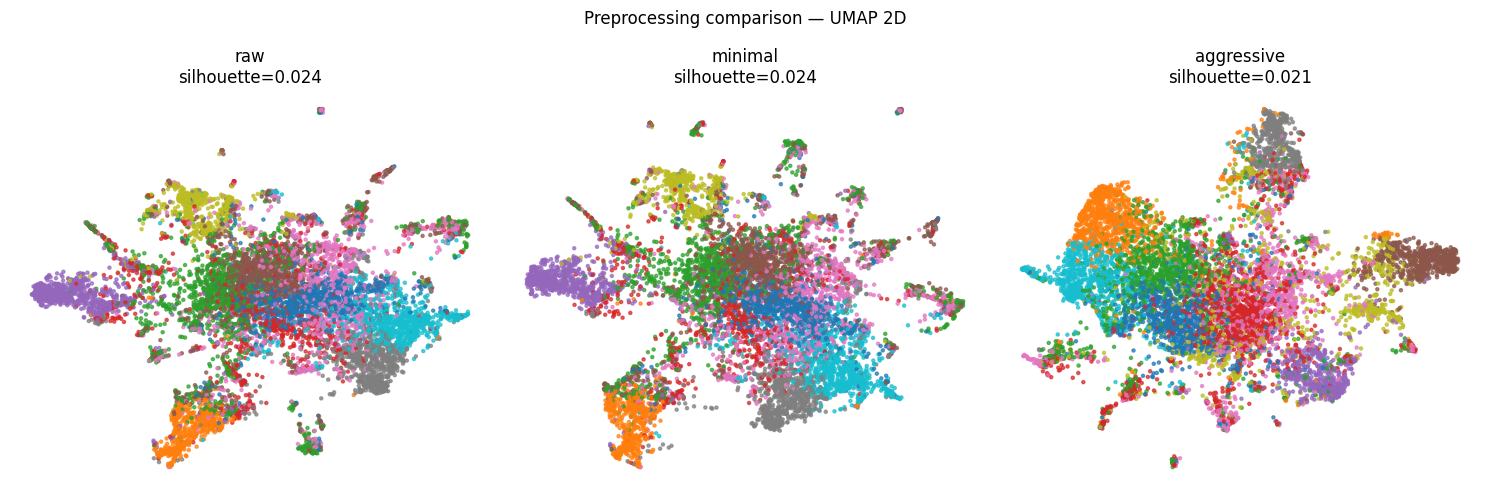

In [5]:
# Visual comparison via UMAP 2D projection
reducer = umap.UMAP(n_components=2, random_state=SEED)

fig, axes = plt.subplots(1, len(pipelines), figsize=(15, 5))
for ax, (name, emb) in zip(axes, embeddings_by_pipeline.items()):
    proj = reducer.fit_transform(emb)
    km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init='auto')
    labels = km.fit_predict(emb)
    ax.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='tab10', s=5, alpha=0.7)
    ax.set_title(f'{name}\nsilhouette={results[name]:.3f}')
    ax.axis('off')

plt.suptitle('Preprocessing comparison — UMAP 2D')
plt.tight_layout()
plt.show()

In [6]:
# Deduplication check — does removing near-duplicates matter?
# Simple exact-dedup check on normalized text
normalized = [preprocess_minimal(t) for t in texts_raw]
unique = set(normalized)
print(f'Total: {len(normalized)}, Unique: {len(unique)}, Duplicates: {len(normalized) - len(unique)}')

Total: 10000, Unique: 9993, Duplicates: 7
